# **EfficientNet Pre-trained Binary Model with Raw Input**

In this notebook we test a pre-trained EfficientNet model to predict Animal vs Non-animal. For this, the original images were used.

## Libraries

In [1]:
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

In [ ]:
# Libraries
import pandas as pd

from deep.constants import ROOT, METADATA_FILE, SEEDS, SCORES
from deep.modelling.model_runs import run_binary_model
from deep.modelling.model_specifications import efficient_net_extended

2025-04-29 22:11:49.762021: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-29 22:11:49.774241: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-29 22:11:49.790441: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-29 22:11:49.794997: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-29 22:11:49.805801: I tensorflow/core/platform/cpu_feature_guar

In [3]:
# Setting options
pd.set_option('display.max_rows', None)

## Data Loading

In [4]:
# Load the metadata
data = pd.read_csv(METADATA_FILE)

# Drop unnecessary columns for this problem
data.drop(columns=['phylum', 'family'], inplace=True)

## Data Preprocessing

In [5]:
# Define path
binary_baseline_path = SCORES / "binary_scores.json"

### Resize Images

In [ ]:
# Resize images
notebook_path = f'"{ROOT}/notebooks/preprocess_routine/resize_routine.ipynb"'
%run $notebook_path

## Data Modelling

### Raw Model

In this section we test which loss function yields the best results

#### Binary CrossEntropy

I0000 00:00:1745961112.352218   15117 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745961112.401806   15117 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745961112.402064   15117 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745961112.403158   15117 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

No baseline score found, saving current as baseline after run.
Found 8108 validated image filenames belonging to 2 classes.
Found 1431 validated image filenames belonging to 2 classes.
Found 2386 validated image filenames belonging to 2 classes.


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 40 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(
/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 8 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(
/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 11 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


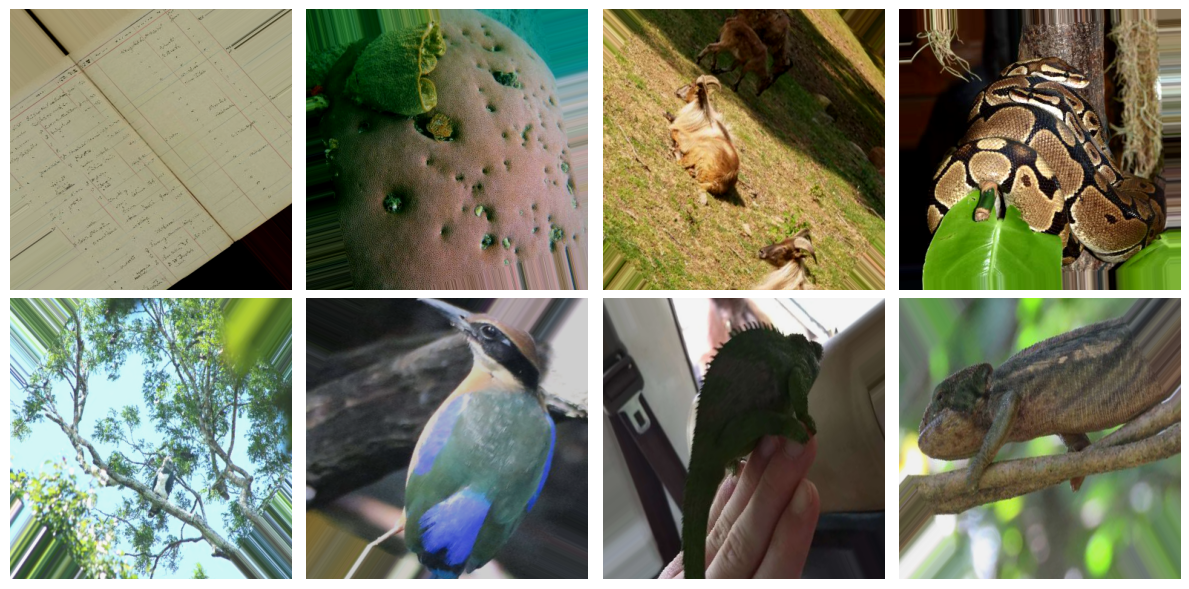

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1745961136.943168   15173 service.cc:146] XLA service 0x738568096a90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745961136.943191   15173 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX350, Compute Capability 6.1
2025-04-29 22:12:17.725824: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-29 22:12:20.349279: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90100
2025-04-29 22:12:26.209345: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:310] gpu_async_0 cuMemAllocAsync failed to allocate 1437078016 bytes: CUDA error: out of memory (CUDA_ERROR_OUT_OF_MEMORY)
 Reported by CUDA: Free memory/Total memory: 249167872/2091253760
2025-04-29 22:12:26.209378: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc

 12/255 ━━━━━━━━━━━━━━━━━━━━ 5:04 1s/step - accuracy: 0.8262 - auc: 0.4281 - loss: 0.5002 - precision: 0.8966 - recall: 0.9132

2025-04-29 22:13:25.501466: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng12{k5=1,k6=0,k7=1,k10=4} for conv (f32[12,48,190,190]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,48,190,190]{3,2,1,0}, f32[48,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=48, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2025-04-29 22:13:25.555100: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.053725231s
Trying algorithm eng12{k5=1,k6=0,k7=1,k10=4} for conv (f32[12,48,190,190]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,48,190,190]{3,2,1,0}, f32[48,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=48, custom_call_targe

254/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.9213 - auc: 0.4933 - loss: 0.3020 - precision: 0.9285 - recall: 0.9914

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2025-04-29 22:21:01.764505: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:310] gpu_async_0 cuMemAllocAsync failed to allocate 2134554112 bytes: CUDA error: out of memory (CUDA_ERROR_OUT_OF_MEMORY)
 Reported by CUDA: Free memory/Total memory: 238682112/2091253760
2025-04-29 22:21:01.764559: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:315] Stats: Limit:                      1806303232
InUse:                      1217637520
MaxInUse:                   1933780820
NumAllocs:                        9281
MaxAllocSize:               1621712896
Reserved:             

255/255 ━━━━━━━━━━━━━━━━━━━━ 561s 2s/step - accuracy: 0.9214 - auc: 0.4933 - loss: 0.3019 - precision: 0.9285 - recall: 0.9914 - val_accuracy: 0.9301 - val_auc: 0.5092 - val_loss: 0.2570 - val_precision: 0.9301 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 449s 2s/step - accuracy: 0.9309 - auc: 0.4686 - loss: 0.2544 - precision: 0.9309 - recall: 1.0000 - val_accuracy: 0.9301 - val_auc: 0.5363 - val_loss: 0.2562 - val_precision: 0.9301 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 458s 2s/step - accuracy: 0.9280 - auc: 0.5129 - loss: 0.2619 - precision: 0.9280 - recall: 1.0000 - val_accuracy: 0.9301 - val_auc: 0.5120 - val_loss: 0.3395 - val_precision: 0.9301 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
254/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.9254 - auc: 0.5081 - loss: 0.2683 - precision: 0.9254 - recall: 1.0000
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257

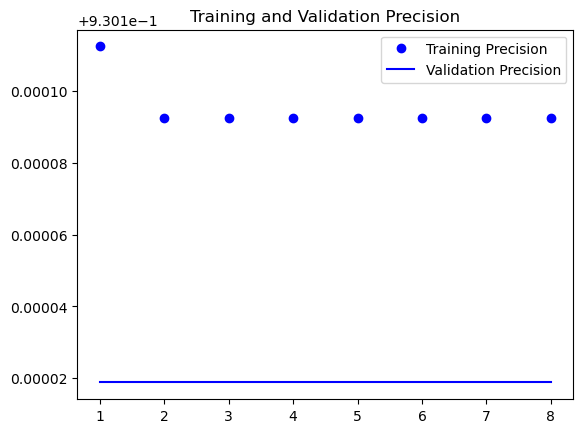

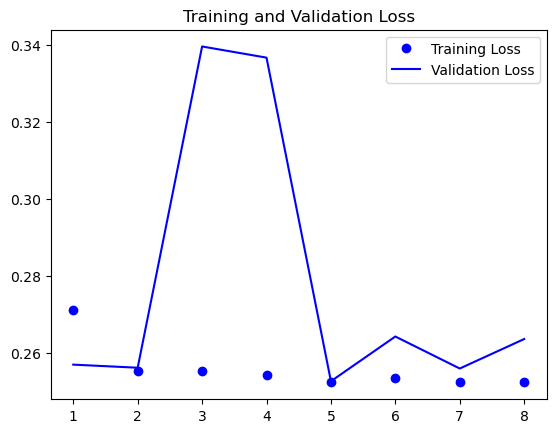

Saved current model as new baseline


In [ ]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net_extended(
        regularizer=False
        ,dropout=False
        ,task_type='binary'
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='original'
    ,model_name='efficientnetb4'
)

#### Focal Loss

Loaded baseline score: 0.9301187992095947
Found 8108 validated image filenames belonging to 2 classes.
Found 1431 validated image filenames belonging to 2 classes.
Found 2386 validated image filenames belonging to 2 classes.


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 40 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(
/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 8 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(
/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 11 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


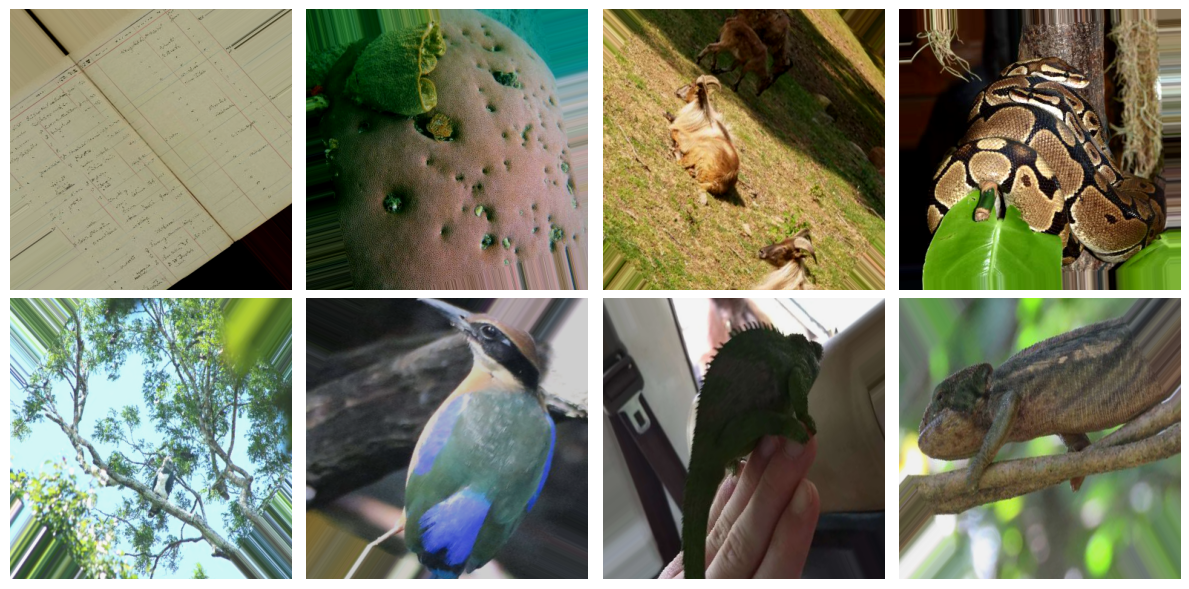

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
254/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.8682 - auc_1: 0.4888 - loss: 0.0079 - precision: 0.9284 - recall: 0.9291

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


255/255 ━━━━━━━━━━━━━━━━━━━━ 493s 2s/step - accuracy: 0.8683 - auc_1: 0.4888 - loss: 0.0079 - precision: 0.9284 - recall: 0.9293 - val_accuracy: 0.1139 - val_auc_1: 0.5129 - val_loss: 0.0082 - val_precision: 0.9701 - val_recall: 0.0488 - learning_rate: 0.0010
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 430s 2s/step - accuracy: 0.9085 - auc_1: 0.5124 - loss: 0.0061 - precision: 0.9319 - recall: 0.9730 - val_accuracy: 0.9301 - val_auc_1: 0.4566 - val_loss: 0.0059 - val_precision: 0.9301 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 438s 2s/step - accuracy: 0.9089 - auc_1: 0.4956 - loss: 0.0064 - precision: 0.9264 - recall: 0.9794 - val_accuracy: 0.9301 - val_auc_1: 0.4921 - val_loss: 0.0061 - val_precision: 0.9301 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
254/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.9154 - auc_1: 0.5138 - loss: 0.0061 - precision: 0.9304 - recall: 0.9826
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00050

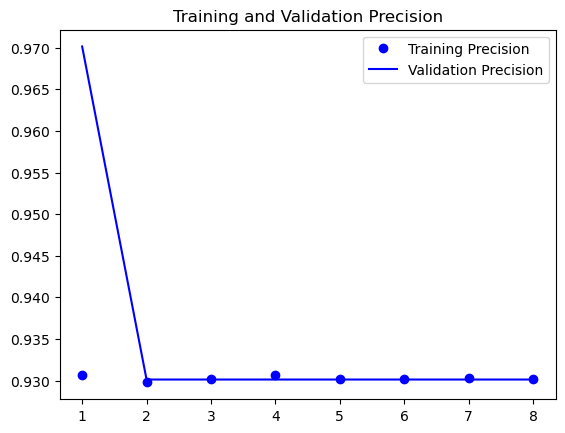

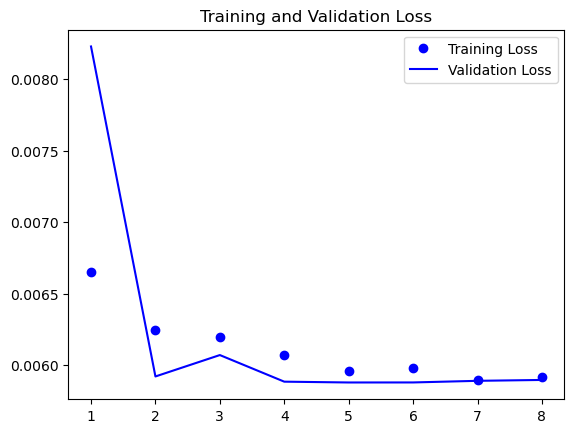

Current model not better than baseline


In [ ]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net_extended(
        regularizer=False
        ,dropout=False
        ,task_type='binary'
    )
    ,loss='focal'
    ,epochs=10
    ,type='original'
    ,model_name='efficientnetb4'
)

The binary crossentropy loss function performed better and so this is the loss function we will be using from now on.

### Model with Regularization

In this section we add L2 regularization to our model and test if it improves the model

Loaded baseline score: 0.9301187992095947
Found 8108 validated image filenames belonging to 2 classes.
Found 1431 validated image filenames belonging to 2 classes.
Found 2386 validated image filenames belonging to 2 classes.


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 40 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(
/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 8 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(
/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 11 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


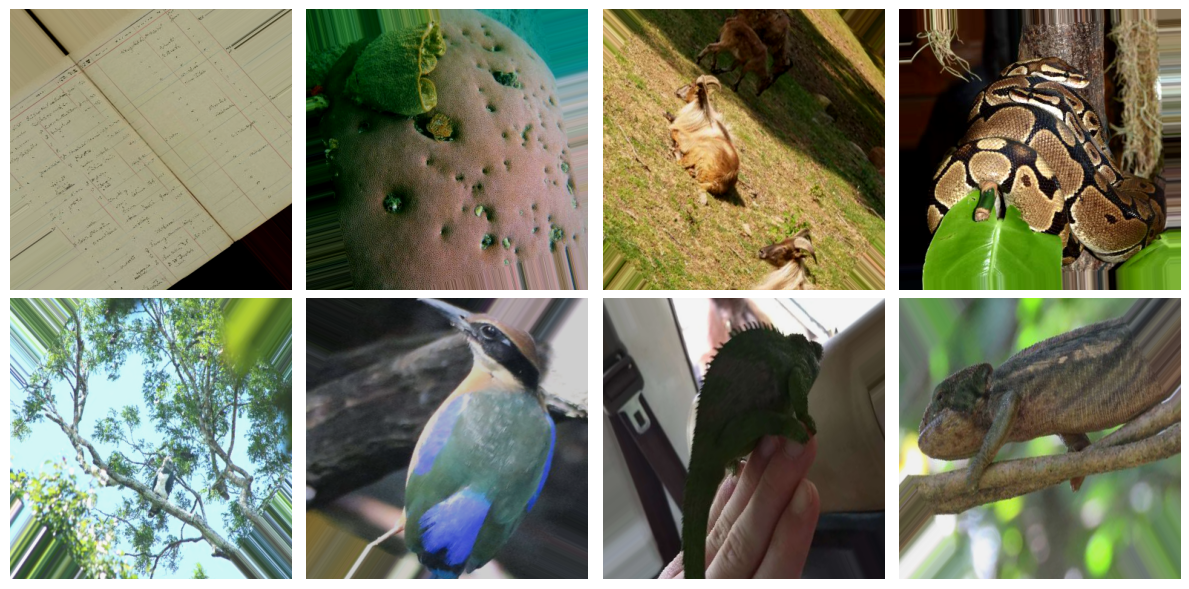

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
254/255 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8971 - auc_2: 0.4785 - loss: 0.4836 - precision: 0.9306 - recall: 0.9622

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


255/255 ━━━━━━━━━━━━━━━━━━━━ 404s 1s/step - accuracy: 0.8972 - auc_2: 0.4786 - loss: 0.4831 - precision: 0.9306 - recall: 0.9623 - val_accuracy: 0.9301 - val_auc_2: 0.5000 - val_loss: 0.4854 - val_precision: 0.9301 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 399s 2s/step - accuracy: 0.9331 - auc_2: 0.5070 - loss: 0.2590 - precision: 0.9331 - recall: 1.0000 - val_accuracy: 0.9301 - val_auc_2: 0.5979 - val_loss: 0.2575 - val_precision: 0.9301 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 413s 2s/step - accuracy: 0.9358 - auc_2: 0.4930 - loss: 0.2421 - precision: 0.9358 - recall: 1.0000 - val_accuracy: 0.9301 - val_auc_2: 0.5748 - val_loss: 0.2740 - val_precision: 0.9301 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 424s 2s/step - accuracy: 0.9314 - auc_2: 0.5362 - loss: 0.2515 - precision: 0.9314 - recall: 1.0000 - val_accuracy: 0.9301 - val_auc_2: 0.4763 - val_loss: 0.2

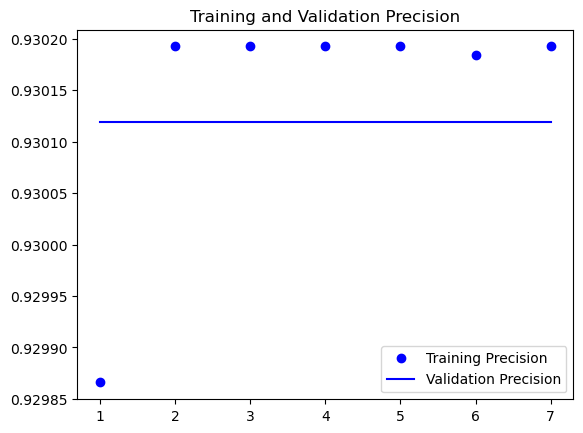

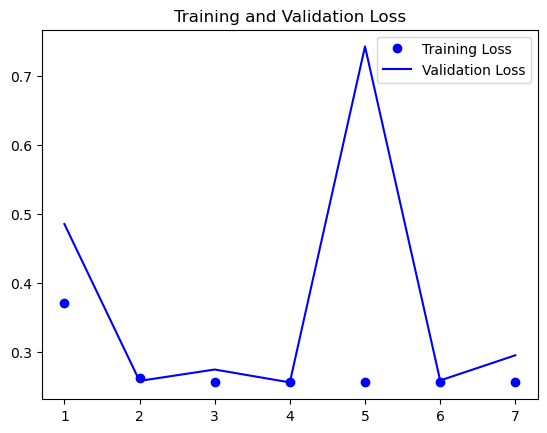

Current model not better than baseline


In [ ]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net_extended(
        regularizer=True
        ,dropout=False
        ,task_type='binary'
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='original'
    ,model_name='efficientnetb4'
)

Regularization did not improve the model.

### Model with Dropout

In this section we add a dropout layer to the model and test if it improves the results.

Loaded baseline score: 0.9301187992095947
Found 8108 validated image filenames belonging to 2 classes.
Found 1431 validated image filenames belonging to 2 classes.
Found 2386 validated image filenames belonging to 2 classes.


/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 40 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(
/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 8 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(
/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 11 invalid image filename(s) in x_col="file_path". These filename(s) will be ignored.
  warnings.warn(


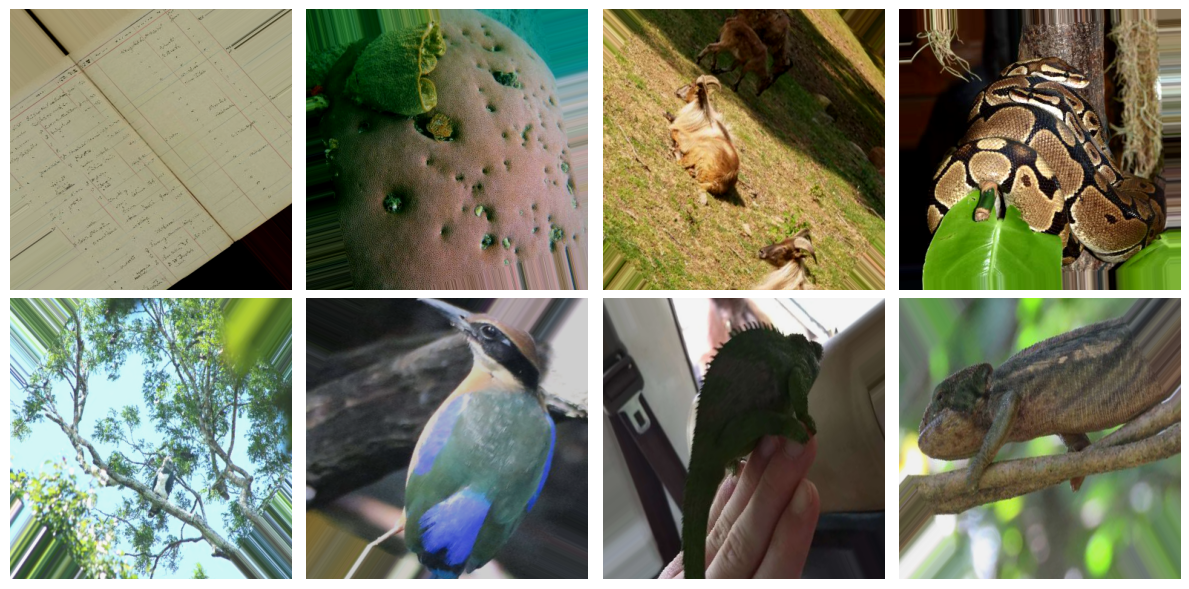

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
254/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.8713 - auc_3: 0.4977 - loss: 0.3701 - precision: 0.9247 - recall: 0.9341

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


255/255 ━━━━━━━━━━━━━━━━━━━━ 501s 2s/step - accuracy: 0.8714 - auc_3: 0.4977 - loss: 0.3698 - precision: 0.9247 - recall: 0.9343 - val_accuracy: 0.0699 - val_auc_3: 0.4474 - val_loss: 1.3271 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 437s 2s/step - accuracy: 0.9309 - auc_3: 0.5042 - loss: 0.2628 - precision: 0.9309 - recall: 1.0000 - val_accuracy: 0.9301 - val_auc_3: 0.4930 - val_loss: 0.3060 - val_precision: 0.9301 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 445s 2s/step - accuracy: 0.9267 - auc_3: 0.4978 - loss: 0.2701 - precision: 0.9267 - recall: 1.0000 - val_accuracy: 0.9301 - val_auc_3: 0.5000 - val_loss: 0.3677 - val_precision: 0.9301 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 446s 2s/step - accuracy: 0.9317 - auc_3: 0.5071 - loss: 0.2578 - precision: 0.9317 - recall: 1.0000 - val_accuracy: 0.9301 - val_auc_3: 0.4898 - val_l

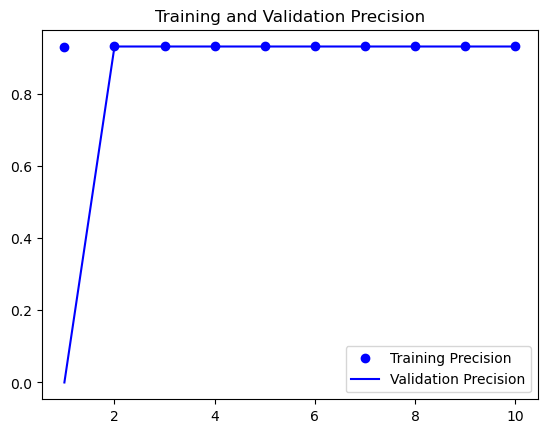

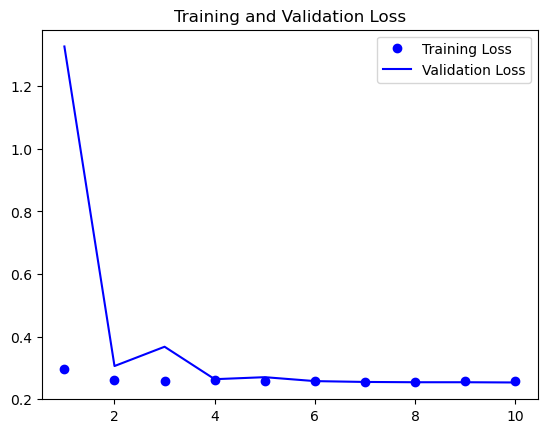

Current model not better than baseline


In [ ]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net_extended(
        regularizer=False
        ,dropout=True
        ,task_type='binary'
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='original'
    ,model_name='efficientnetb4'
)

The dropout layer did not improve the model.

Now, we will attempt to transform the input images and recheck the model.